In [1]:
# Mount Google Drive folder as a local folder
# Note: This mounts your entire drive, not the current folder
from google.colab import drive
drive.mount('/mydrive')

Mounted at /mydrive


In [2]:
#TODO replace the path with your path in drive
#This usually takes 15-20 minutes to run
!cp -r /mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset ./

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, Model

In [4]:
# TRAIN_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/train/'
# TEST_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/test/'
TRAIN_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/train/'
TEST_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/test/'
SIZE = (224, 224)

In [5]:
labels = []
for class_ in os.listdir(TRAIN_PATH):
    labels.append(class_)
NUM_LABELS = len(labels)

print(labels)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(rescale=1./255, validation_split = 0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

'''
Comments:
- ImageDataGenerator will resize all images to target_size
- x_col is the column where the images' names are
- y_col is the column where the labels are
- has_ext means that the images' names include a file extension, e.g. image_name.jpg
- Here you can change the targe_size to resize all images to different shapes.
Maybe larger images help in getting a better accuracy
'''
train_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TRAIN_PATH,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="training",
                                                 class_mode='categorical')

val_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TEST_PATH ,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="validation",
                                                 class_mode='categorical')

Found 9813 images belonging to 6 classes.
Found 268 images belonging to 6 classes.


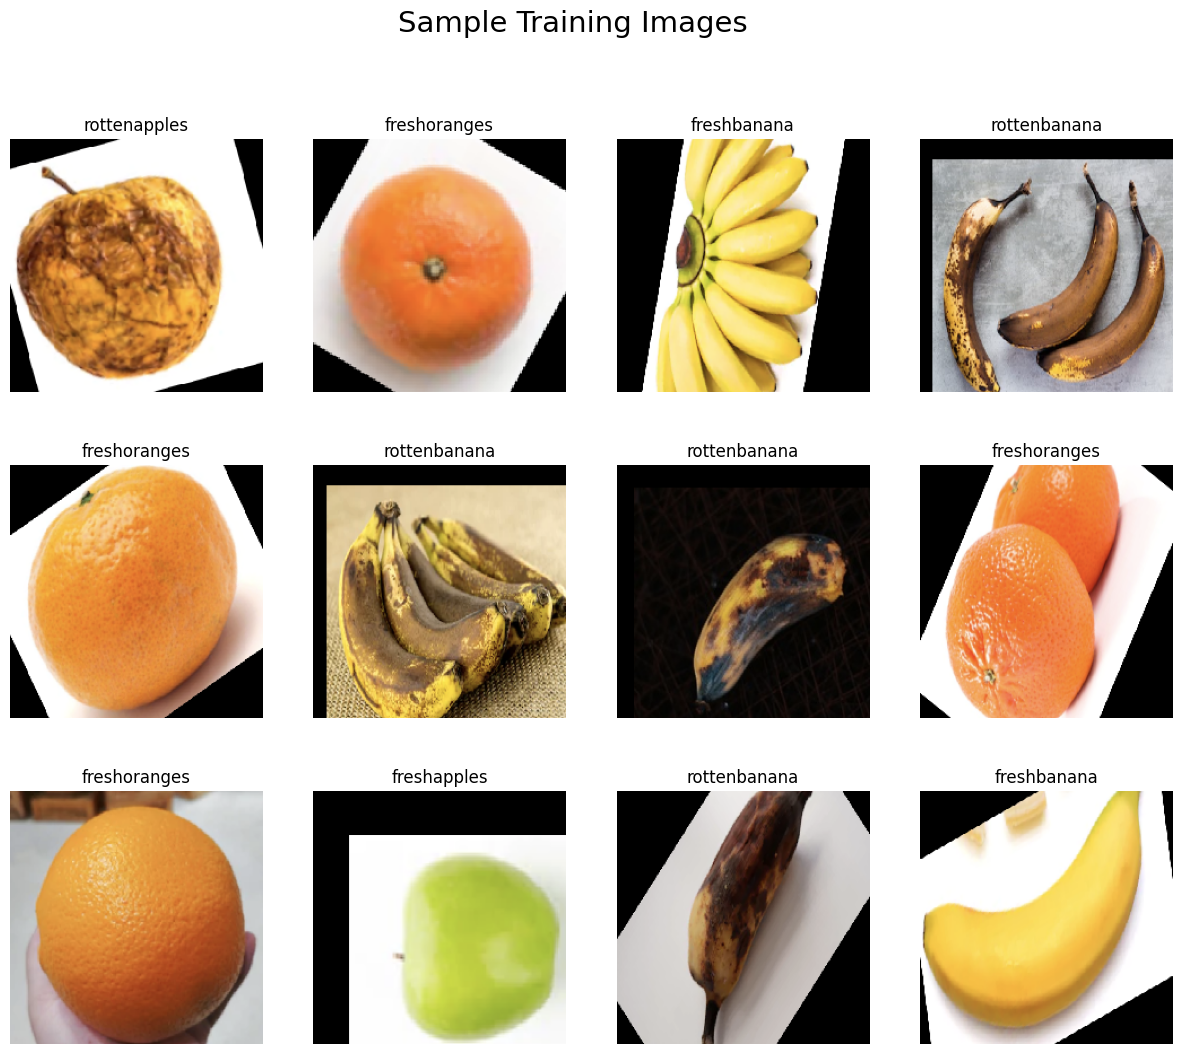

In [7]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(15, 12))
idx = 0

for i in range(3):
    for j in range(4):
        label = labels[np.argmax(train_dataset[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_dataset[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

# plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

In [8]:
from tensorflow.keras.applications import ConvNeXtBase

In [9]:
from keras.models import Model
from keras.layers import Input, Dense
from tensorflow.keras.optimizers import  Adam


In [23]:
# Base feature extractor
base_model = ConvNeXtBase(
    include_top=False,       # ❗ Exclude top = no classifier
    weights='imagenet',       # ✅ You can set None if you want full random
    input_tensor=Input(shape=(224, 224, 3))
)

# Add your custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(6, activation='softmax')(x)  # For your 6 classes

# Full model
model = Model(inputs=base_model.input, outputs=output)



In [24]:

from keras.callbacks import LearningRateScheduler

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import keras
from keras.layers import *
from keras.models import *
from keras.preprocessing import image
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [26]:
model.compile(loss='categorical_crossentropy',optimizer="adam",metrics=['accuracy'])
model.summary()
epochs = 30
stepsperepoch=187
validationsteps=1
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)
es = EarlyStopping(monitor='val_acc', mode='max', verbose=1, patience=100)
mc = ModelCheckpoint("resnet50.h5", monitor='val_loss',save_best_only=True, mode='min',verbose=1)

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_pres… │ (None, 224, 224,  │          0 │ input_layer_21[0… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stem  │ (None, 56, 56,    │      6,528 │ convnext_base_pr… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │      6,400 │ convnext_base_st… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        128 │ convnext_base_st… │
│ (LayerScale)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │          0 │ convnext_base_st… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_144 (Add)       │ (None, 56, 56,    │          0 │ convnext_base_st… │
│                     │ 128)              │            │ convnext_base_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │      6,400 │ add_144[0][0]     │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        256 │ convnext_base_st… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     66,048 │ convnext_base_st… │
│ (Dense)             │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │          0 │ convnext_base_st… │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │     65,664 │ convnext_base_st… │
│ (Dense)             │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_base_stag… │ (None, 56, 56,    │        128 │ convnext_base_st

 Total params: 87,572,614 (334.06 MB)

 Trainable params: 87,572,614 (334.06 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
hist = model.fit(
    train_dataset,
    epochs=epochs,
    callbacks=[annealer,mc,es],
    steps_per_epoch=stepsperepoch,
    validation_data= val_dataset,
    validation_steps = validationsteps
)

Epoch 1/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.1797 - loss: 2.4669
Epoch 1: val_loss improved from inf to 1.76689, saving model to resnet50.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 170s 501ms/step - accuracy: 0.1798 - loss: 2.4644 - val_accuracy: 0.2500 - val_loss: 1.7669 - learning_rate: 0.0010
Epoch 2/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 20s 311ms/step - accuracy: 0.1973 - loss: 1.8117
Epoch 2: val_loss did not improve from 1.76689
187/187 ━━━━━━━━━━━━━━━━━━━━ 38s 201ms/step - accuracy: 0.1975 - loss: 1.8114 - val_accuracy: 0.2188 - val_loss: 1.7878 - learning_rate: 9.5000e-04
Epoch 3/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.1942 - loss: 1.8111
Epoch 3: val_loss did not improve from 1.76689
187/187 ━━━━━━━━━━━━━━━━━━━━ 56s 298ms/step - accuracy: 0.1942 - loss: 1.8111 - val_accuracy: 0.2500 - val_loss: 1.7694 - learning_rate: 9.0250e-04
Epoch 4/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 0.1696 - loss: 1.8105
Epoch 4: val_loss did not improve from 1.76689
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 192ms/step - accuracy: 0.1750 - loss: 1.8104 - val_accuracy: 0.2188 - val_loss: 1.8210 - learning_rate: 8.5737e-04
Epoc

187/187 ━━━━━━━━━━━━━━━━━━━━ 41s 220ms/step - accuracy: 0.1833 - loss: 1.8075 - val_accuracy: 0.3125 - val_loss: 1.7311 - learning_rate: 7.7378e-04
Epoch 7/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.2060 - loss: 1.7889
Epoch 7: val_loss did not improve from 1.73109
187/187 ━━━━━━━━━━━━━━━━━━━━ 56s 299ms/step - accuracy: 0.2060 - loss: 1.7890 - val_accuracy: 0.2188 - val_loss: 1.7907 - learning_rate: 7.3509e-04
Epoch 8/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 19s 296ms/step - accuracy: 0.2049 - loss: 1.7934
Epoch 8: val_loss did not improve from 1.73109
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 191ms/step - accuracy: 0.2055 - loss: 1.7933 - val_accuracy: 0.2812 - val_loss: 1.7670 - learning_rate: 6.9834e-04
Epoch 9/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.2100 - loss: 1.7968
Epoch 9: val_loss did not improve from 1.73109
187/187 ━━━━━━━━━━━━━━━━━━━━ 56s 298ms/step - accuracy: 0.2100 - loss: 1.7968 - val_accuracy: 0.2188 - val_loss: 1.8128 - learning_rate: 6.6342e-04
Ep

187/187 ━━━━━━━━━━━━━━━━━━━━ 59s 314ms/step - accuracy: 0.2060 - loss: 1.7818 - val_accuracy: 0.3438 - val_loss: 1.7271 - learning_rate: 3.5849e-04
Epoch 22/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 21s 320ms/step - accuracy: 0.2174 - loss: 1.7801
Epoch 22: val_loss did not improve from 1.72714
187/187 ━━━━━━━━━━━━━━━━━━━━ 39s 206ms/step - accuracy: 0.2181 - loss: 1.7809 - val_accuracy: 0.1875 - val_loss: 1.7540 - learning_rate: 3.4056e-04
Epoch 23/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.2175 - loss: 1.7799
Epoch 23: val_loss did not improve from 1.72714
187/187 ━━━━━━━━━━━━━━━━━━━━ 56s 299ms/step - accuracy: 0.2175 - loss: 1.7799 - val_accuracy: 0.3125 - val_loss: 1.7682 - learning_rate: 3.2353e-04
Epoch 24/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 0.2051 - loss: 1.7831
Epoch 24: val_loss did not improve from 1.72714
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 192ms/step - accuracy: 0.2065 - loss: 1.7820 - val_accuracy: 0.3438 - val_loss: 1.8260 - learning_rate: 3.0736

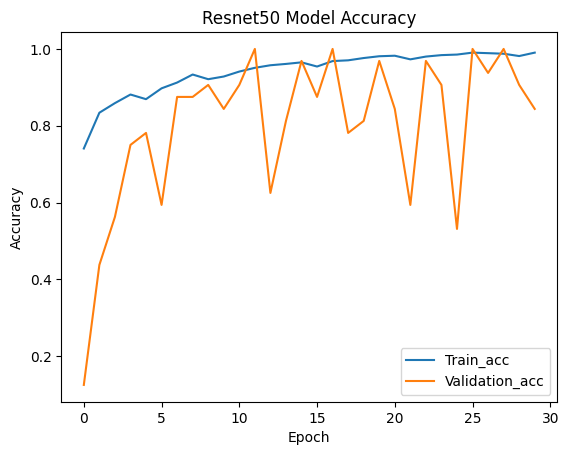

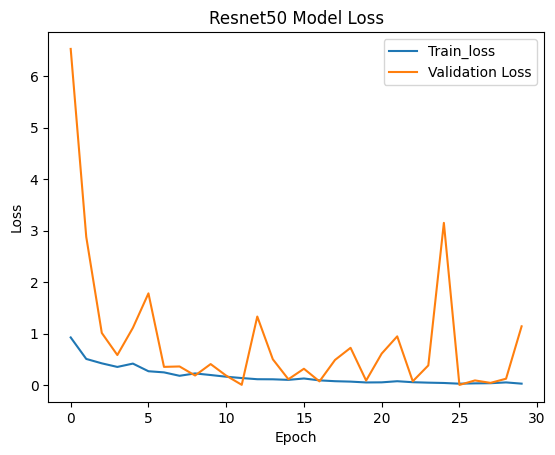

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Resnet50 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(["Train_acc","Validation_acc"])
plt.show()

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Resnet50 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(["Train_loss","Validation Loss"])
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(TEST_PATH,
                                                  batch_size=1,
                                                  target_size=SIZE,
                                                  shuffle = False,
                                                  classes=labels,
                                                  class_mode='categorical')


filenames = test_generator.filenames
nb_samples = len(filenames)

loss, acc = model.evaluate(test_generator,steps = (nb_samples), verbose=1)
print('accuracy test: ',acc)
print('loss test: ',loss)

Found 2698 images belonging to 6 classes.
2698/2698 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8006 - loss: 1.2632
accuracy test:  0.8306152820587158
loss test:  1.1303296089172363


In [ ]:
predictions = model.predict(test_generator)
files=test_generator.filenames
class_dict=test_generator.class_indices # a dictionary of the form class name: class index
rev_dict={}
for key, value in class_dict.items():
    rev_dict[value]=key

for i, p in enumerate(predictions):
    index=np.argmax(p)
    klass=rev_dict[index]
    prob=p[index]

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


2698/2698 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step


In [ ]:
print(len(test_generator[0][0]))
print(test_generator[0][1].shape)

1
(1, 6)


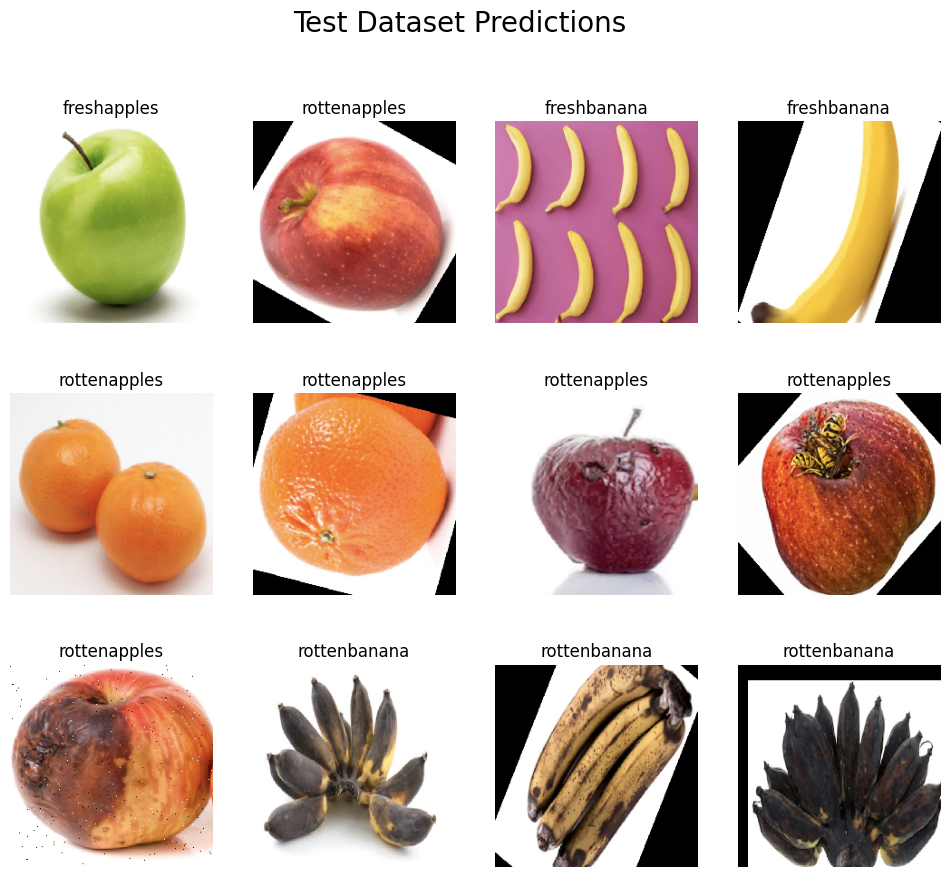

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(12, 10))
idx = 0

for i in range(3):
    for j in range(4):
        predicted_label = labels[np.argmax(predictions[idx])]
        ax[i, j].set_title(f"{predicted_label}")
        ax[i, j].imshow(test_generator[idx][0].reshape(224,224,3))
        ax[i, j].axis("off")
        idx += 200

# plt.tight_layout()
plt.suptitle("Test Dataset Predictions", fontsize=20)
plt.show()

In [ ]:
!apt-get install graphviz -y # Install Graphviz if it's not already installed
!pip install pydot

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [ ]:
# from tensorflow.keras.utils import plot_model
# tf.keras.utils.plot_model(
# model, to_file='model.png', show_shapes=True, show_dtype=False,
# show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
# )

"dot" with args ['-Tpng', '/tmp/tmpdmc83ahi/tmpgddh6swp'] returned code: -6

stdout, stderr:
 b''
b"failed at node 10274[1]\ndot: maze.c:313: chkSgraph: Assertion `np->cells[1]' failed.\n"



AssertionError: "dot" with args ['-Tpng', '/tmp/tmpdmc83ahi/tmpgddh6swp'] returned code: -6

In [ ]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 17.1 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras import layers
from collections import defaultdict
# from PIL import ImageFont
# font = ImageFont.truetype("arial.ttf", 12)
color_map = defaultdict(dict) #customize the colours
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.Dropout]['fill'] = '#03045e'
color_map[layers.Dense]['fill'] = '#fb5607'
color_map[layers.Flatten]['fill'] = '#ffbe0b'
# visualkeras.layered_view(model, legend=True,color_map=color_map,scale_xy=2, scale_z=1, max_z=200)

In [ ]:
test_steps_per_epoch = int(np.ceil(test_generator.samples / test_generator.batch_size))

In [ ]:

predictions = model.predict(test_generator, steps=test_steps_per_epoch)
# Get most likely class
predicted_classes = np.argmax(predictions, axis=1)

2698/2698 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step


In [ ]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

               precision    recall  f1-score   support

  freshapples       1.00      0.85      0.92       395
  freshbanana       0.99      0.98      0.99       381
 freshoranges       1.00      0.12      0.22       388
 rottenapples       0.62      0.99      0.76       601
 rottenbanana       0.99      1.00      0.99       530
rottenoranges       0.81      0.89      0.85       403

     accuracy                           0.83      2698
    macro avg       0.90      0.81      0.79      2698
 weighted avg       0.88      0.83      0.80      2698



In [ ]:
print('Confusion Matrix')
# print(confusion_matrix(test_generator.classes, predicted_classes))
cm = confusion_matrix(test_generator.classes, predicted_classes)

Confusion Matrix


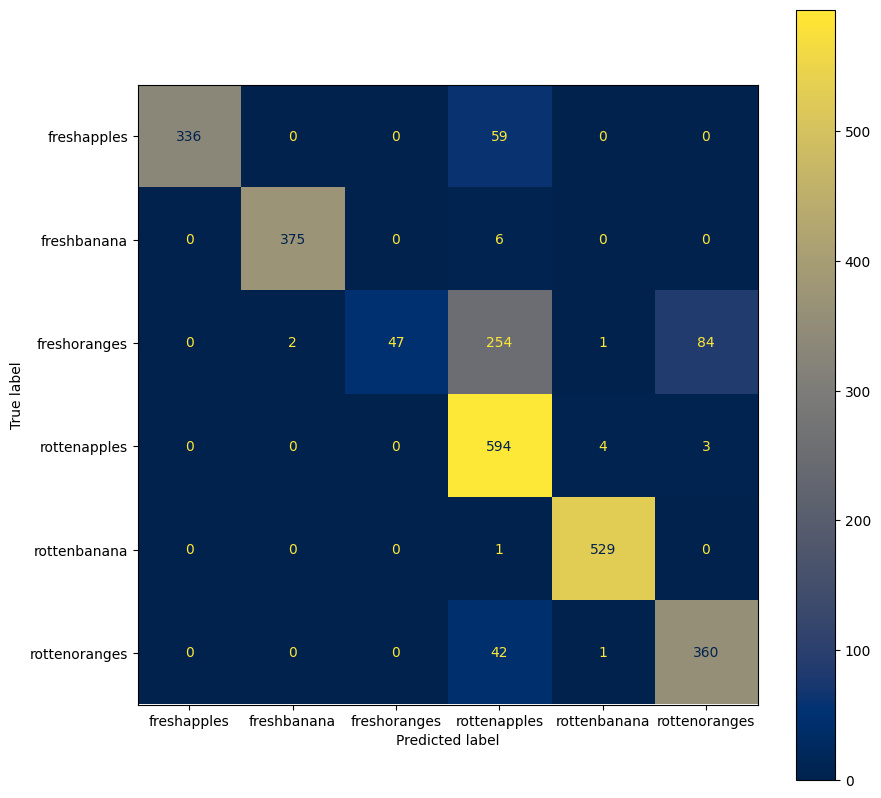

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_generator.classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap="cividis")